In [1]:
from pathlib import Path
import sys
import os

notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
os.chdir(str(project_root))
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.75)
pd.set_option('display.float_format', '{:.3f}'.format)

# Generalization: Specialized vs. Full Training

**Left:** 332_h (head-only training) vs 332 (training on all anatomy) on **body** test datasets.  
**Right:** 332_mri (MRI-only training) vs 332 (training on all modalities) on **CT** test datasets.

In [2]:
# Offsets to load (pick one or loop over both)
offsets = [5, 12]

def clean_name(name):
    return name.split("_", 1)[1] if "_" in name else name

def load_results(prefix, offset):
    path = f"evaluation/benchmark_universeg/{prefix}_offset_{offset}.pkl"
    raw = pd.read_pickle(path)
    df = pd.DataFrame(raw)
    df["dataset"] = df["name"].apply(clean_name)
    return df

# ---------- body comparison: 332_h (head) vs 332 (all) ----------
body_h = {}
body_all = {}
for offset in offsets:
    body_h[offset] = load_results("body_results_p_unet_332_h", offset)
    body_all[offset] = load_results("body_results_p_unet_332", offset)

# ---------- ct comparison: 332_mri (mri) vs 332 (all) ----------
ct_mri = {}
ct_all = {}
for offset in offsets:
    ct_mri[offset] = load_results("ct_results_p_unet_332_mri", offset)
    ct_all[offset] = load_results("ct_results_p_unet_332", offset)

print("Loaded body and CT results for offsets:", offsets)

Loaded body and CT results for offsets: [5, 12]


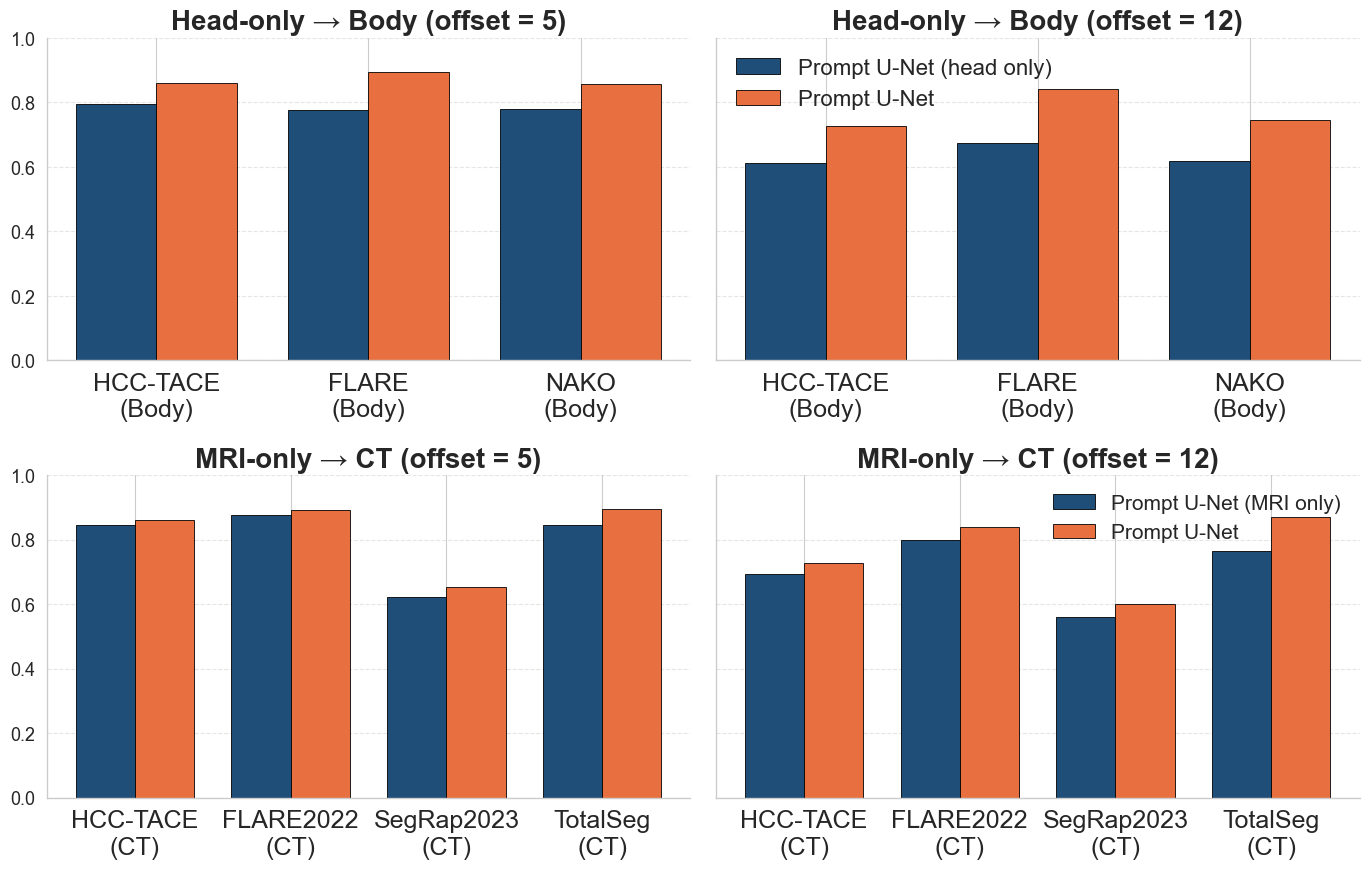

In [13]:
import numpy as np

offset_pair = [5, 12]

# ── Dataset grouping ─────────────────────────────────────────────────────────
# Body test datasets (head-only → body generalization)
DATASET_GROUP_BODY = {
    "nako_body": "NAKO (Body)",
    "flare":     "FLARE (Body)",
    "hcc_tase":  "HCC-TACE (Body)",
}
DS_ORDER_BODY = ["HCC-TACE (Body)", "FLARE (Body)", "NAKO (Body)"]
DATASET_DISPLAY_BODY = {
    "NAKO (Body)":      "NAKO\n(Body)",
    "FLARE (Body)":     "FLARE\n(Body)",
    "HCC-TACE (Body)":  "HCC-TACE\n(Body)",
}

# CT test datasets (MRI-only → CT generalization)
DATASET_GROUP_CT = {
    "flare":        "FLARE_2022 (CT)",
    "hcc_tase":     "HCC-TACE (CT)",
    "seg_rap":      "SegRap_2023 (CT)",
    "total_seg_ct": "TotalSeg (CT)",
}
DS_ORDER_CT = ["HCC-TACE (CT)", "FLARE_2022 (CT)", "SegRap_2023 (CT)", "TotalSeg (CT)"]
DATASET_DISPLAY_CT = {
    "FLARE_2022 (CT)":   "FLARE2022\n(CT)",
    "HCC-TACE (CT)":     "HCC-TACE\n(CT)",
    "SegRap_2023 (CT)":  "SegRap2023\n(CT)",
    "TotalSeg (CT)":     "TotalSeg\n(CT)",
}

# ── Colors ──────────────────────────────────────────────────────────────────
colors = {
    "specialized": "#1f4e79",   # head-only / MRI-only
    "full":        "#E87040",   # full training / all modalities
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
width = 0.38

for col, offset in enumerate(offset_pair):

    # ==========================================================
    # TOP ROW: Head-only → Body
    # ==========================================================
    ax = axes[0, col]

    bh = body_h[offset].copy()
    ba = body_all[offset].copy()
    bh["ds_group"] = bh["dataset"].map(DATASET_GROUP_BODY)
    ba["ds_group"] = ba["dataset"].map(DATASET_GROUP_BODY)

    body_h_agg = bh.groupby("ds_group")["dice"].mean()
    body_all_agg = ba.groupby("ds_group")["dice"].mean()

    punet_vals = [body_h_agg.get(ds, np.nan) for ds in DS_ORDER_BODY]
    full_vals  = [body_all_agg.get(ds, np.nan) for ds in DS_ORDER_BODY]

    x = np.arange(len(DS_ORDER_BODY))

    ax.bar(x - width / 2, punet_vals, width=width,
           label="Prompt U-Net (head only)", color=colors["specialized"],
           edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, full_vals, width=width,
           label="Prompt U-Net", color=colors["full"],
           edgecolor="black", linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_DISPLAY_BODY[ds] for ds in DS_ORDER_BODY],
                       ha="center", fontsize=13)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"Head-only → Body (offset = {offset})", fontsize=20, weight="bold")
    # ax.tick_params(axis='both', labelsize=12)
    ax.tick_params(axis='y', labelsize=13)
    ax.tick_params(axis='x', labelsize=18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # ==========================================================
    # BOTTOM ROW: MRI-only → CT
    # ==========================================================
    ax = axes[1, col]

    cm = ct_mri[offset].copy()
    ca = ct_all[offset].copy()
    cm["ds_group"] = cm["dataset"].map(DATASET_GROUP_CT)
    ca["ds_group"] = ca["dataset"].map(DATASET_GROUP_CT)

    ct_mri_agg = cm.groupby("ds_group")["dice"].mean()
    ct_all_agg = ca.groupby("ds_group")["dice"].mean()

    punet_vals = [ct_mri_agg.get(ds, np.nan) for ds in DS_ORDER_CT]
    full_vals  = [ct_all_agg.get(ds, np.nan) for ds in DS_ORDER_CT]

    x = np.arange(len(DS_ORDER_CT))

    ax.bar(x - width / 2, punet_vals, width=width,
           label="Prompt U-Net (MRI only)", color=colors["specialized"],
           edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, full_vals, width=width,
           label="Prompt U-Net", color=colors["full"],
           edgecolor="black", linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_DISPLAY_CT[ds] for ds in DS_ORDER_CT],
                       ha="center", fontsize=13)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"MRI-only → CT (offset = {offset})", fontsize=20, weight="bold")
    # ax.tick_params(axis='both', labelsize=12)
    ax.tick_params(axis='y', labelsize=13)
    ax.tick_params(axis='x', labelsize=18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# ----------------------------------------------------------
# Shared formatting
# ----------------------------------------------------------
axes[0, 1].tick_params(axis="y", labelleft=False)
axes[1, 1].tick_params(axis="y", labelleft=False)

axes[0, 1].legend(frameon=False, fontsize=16, loc="upper left")
axes[1, 1].legend(frameon=False, fontsize=15, loc="upper right")

plt.tight_layout()
plt.savefig("evaluation/benchmark_universeg/generalization_2d.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
print("=== Overall Average Dice ===\n")
for offset in offsets:
    h_mean = body_h[offset]["dice"].mean()
    h_std  = body_h[offset]["dice"].std()
    all_mean = body_all[offset]["dice"].mean()
    all_std  = body_all[offset]["dice"].std()

    mri_mean = ct_mri[offset]["dice"].mean()
    mri_std  = ct_mri[offset]["dice"].std()
    ct_all_mean = ct_all[offset]["dice"].mean()
    ct_all_std  = ct_all[offset]["dice"].std()

    print(f"Offset {offset}  —  Body datasets:")
    print(f"  332_h  (head only) : {h_mean:.3f} ± {h_std:.3f}  (n={len(body_h[offset])})")
    print(f"  332    (all)        : {all_mean:.3f} ± {all_std:.3f}  (n={len(body_all[offset])})")
    print(f"Offset {offset}  —  CT datasets:")
    print(f"  332_mri (MRI only)  : {mri_mean:.3f} ± {mri_std:.3f}  (n={len(ct_mri[offset])})")
    print(f"  332     (all)        : {ct_all_mean:.3f} ± {ct_all_std:.3f}  (n={len(ct_all[offset])})")
    print()

=== Overall Average Dice ===

Offset 5  —  Body datasets:
  332_h  (head only) : 0.815 ± 0.137  (n=300)
  332    (all)        : 0.871 ± 0.104  (n=300)
Offset 5  —  CT datasets:
  332_mri (MRI only)  : 0.798 ± 0.173  (n=400)
  332     (all)        : 0.826 ± 0.168  (n=400)

Offset 12  —  Body datasets:
  332_h  (head only) : 0.639 ± 0.230  (n=300)
  332    (all)        : 0.771 ± 0.187  (n=300)
Offset 12  —  CT datasets:
  332_mri (MRI only)  : 0.705 ± 0.202  (n=400)
  332     (all)        : 0.760 ± 0.195  (n=400)

